# EMPOT Alignment Benchmark: Rotation & Translation Recovery

This notebook evaluates **EMPOT**'s alignment accuracy on subtomogram point clouds under controlled perturbations.

**EMPOT** uses Unbalanced Gromov-Wasserstein (UGW) optimal transport to match internal point-cloud geometry, then recovers the rigid transform (rotation + translation) via the Kabsch/SVD algorithm.

Three experiments:
1. **Rotation only** — sweep rotation magnitudes from 5° to 60°
2. **Translation only** — sweep translation magnitudes
3. **Combined** — paired rotation + translation perturbations

> **Kernel**: Use the `EMPOT/.venv` Python environment (has `unbalancedgw`, `torch`, etc.)

In [2]:
%matplotlib inline

import sys
import os
import contextlib
import io
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import mrcfile
import torch
from scipy.spatial.transform import Rotation

# Add EMPOT/src to path for trn and coords imports
sys.path.insert(0, os.path.abspath('../src'))
import trn

from unbalancedgw.vanilla_ugw_solver import log_ugw_sinkhorn
from unbalancedgw._vanilla_utils import l2_distortion

plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["font.size"] = 12

In [3]:
def normalize_volume(volume):
    """Normalize a 3D volume to [0, 1]."""
    volume = volume.astype(np.float32)
    volume = volume - volume.min()
    vmax = float(volume.max())
    if vmax <= 0:
        raise ValueError("Volume is constant after normalization.")
    return volume / (vmax + 1e-8)


def sample_normalized_volume(volume, threshold, num_points, random_seed=None):
    """
    Sample pseudo-atoms from a normalized volume using TRN.
    Returns an (M, 3) numpy array of point coordinates (voxel-index space).
    """
    map_th = volume.copy()
    map_th[map_th < threshold] = 0
    if float(map_th.sum()) <= 0:
        raise ValueError(f"Threshold {threshold} zeroes out the entire volume.")

    with contextlib.redirect_stdout(io.StringIO()):
        rm0, arr_flat, arr_idx, xyz, coords_1d = trn.trn_rm0(
            map_th, M=num_points, random_seed=random_seed,
        )
        rms, rs, ts_save = trn.trn_iterate(
            rm0, arr_flat, arr_idx, xyz,
            n_save=10, e0=0.3, ef=0.05,
            l0=0.005 * num_points, lf=0.5,
            tf=num_points * 8,
            do_log=True, log_n=10,
        )
    return rms[-1]  # shape (M, 3)


def random_axis(rng):
    """Generate a random unit vector for rotation axis."""
    v = rng.normal(size=3)
    return v / np.linalg.norm(v)


def random_direction(rng):
    """Generate a random unit direction vector for translation."""
    v = rng.normal(size=3)
    return v / np.linalg.norm(v)


def run_empot_alignment(pts_ref, pts_tgt,
                         eps=2000, rho=100000, rho2=100000,
                         nits_plan=100, nits_sinkhorn=100):
    """
    Run the full EMPOT alignment pipeline: UGW -> correspondences -> Kabsch SVD.

    Args:
        pts_ref: (N, 3) numpy array — reference (original) point cloud
        pts_tgt: (M, 3) numpy array — target (transformed) point cloud

    Returns:
        Abar:        centroid of matched reference points
        Bbar:        centroid of matched target points
        R_recovered: scipy Rotation that maps centered target -> centered reference
        dist:        UGW distortion score
    """
    n_ref = len(pts_ref)
    n_tgt = len(pts_tgt)

    # Uniform weights
    a = np.ones(n_ref) / n_ref
    b = np.ones(n_tgt) / n_tgt

    # Intra-cloud squared pairwise distance matrices (vectorized)
    dx = np.sum((pts_ref[:, None, :] - pts_ref[None, :, :]) ** 2, axis=-1)
    dy = np.sum((pts_tgt[:, None, :] - pts_tgt[None, :, :]) ** 2, axis=-1)

    # Solve UGW
    a_t = torch.from_numpy(a)
    b_t = torch.from_numpy(b)
    dx_t = torch.from_numpy(dx)
    dy_t = torch.from_numpy(dy)

    pi, gamma = log_ugw_sinkhorn(
        a_t, dx_t, b_t, dy_t, init=None, eps=eps,
        rho=rho, rho2=rho2,
        nits_plan=nits_plan, tol_plan=1e-10,
        nits_sinkhorn=nits_sinkhorn, tol_sinkhorn=1e-10,
        two_outputs=True,
    )

    dist = float(l2_distortion(pi, gamma, dx_t, dy_t))

    # Build correspondences: for each target point, find best-matching ref point
    pi_np = np.array(pi)
    all_coup = []
    for i in range(n_tgt):
        j = int(np.argmax(pi_np[:, i]))
        if pi_np[j, i] > 0:
            all_coup.append((i, j))  # (target_idx, reference_idx)

    # Kabsch SVD alignment
    A = np.array([pts_ref[c[1]] for c in all_coup])  # matched reference points
    B = np.array([pts_tgt[c[0]] for c in all_coup])   # matched target points

    Abar = A.mean(axis=0)
    Bbar = B.mean(axis=0)

    H = (A - Abar).T @ (B - Bbar)
    U, S, V = np.linalg.svd(H)

    # Ensure proper rotation (det = +1)
    d = np.linalg.det(U @ V)
    R = U @ np.diag([1.0, 1.0, d]) @ V

    R_recovered = Rotation.from_matrix(R)
    return Abar, Bbar, R_recovered, dist


def rotation_error_deg(R_true, R_recovered):
    """
    Compute rotation recovery error in degrees.

    R_recovered should approximate R_true^{-1} (maps target -> source).
    Error = angular magnitude of (R_recovered * R_true), which should be identity.
    """
    R_diff = R_recovered * R_true
    return np.degrees(R_diff.magnitude())


def translation_error(t_true, R_true, Abar, Bbar, R_recovered):
    """
    Compute translation recovery error (Euclidean distance).

    The recovered transform: source = R_rec @ target + (Abar - R_rec @ Bbar)
    So the recovered inverse-translation: t_rec = Abar - R_rec.apply(Bbar)
    The true inverse-translation:         t_inv = -R_true_inv.apply(t_true)
    Error = ||t_rec - t_inv||
    """
    t_rec = Abar - R_recovered.apply(Bbar)
    t_true_inv = -R_true.inv().apply(t_true)
    return float(np.linalg.norm(t_rec - t_true_inv))

## Configuration

In [7]:
# ── Data & Sampling ──────────────────────────────────────────────
cluster_dir = Path("../../Data/0.1/Cluster_0")

N = 3                  # number of subtomograms to select
num_points = 500        # pseudo-atoms per point cloud
threshold = 0.7         # TRN sampling threshold on normalized volume
experiment_seed = 1337    # master seed for reproducibility

# ── Experiment 1: rotation magnitudes (degrees) ─────────────────
rotation_angles_deg = [i for i in range(60, 180, 10)]

# ── Experiment 2: translation magnitudes (voxel units) ──────────
translation_magnitudes = [1, 2, 3, 4, 5]

# ── Experiment 3: combined (angle_deg, translation_mag) pairs ───
combined_pairs = [(5, 2), (10, 5), (20, 7), (30, 10), (40, 15)]

## Data Loading & Point-Cloud Sampling

In [8]:
# Discover subtomograms (filter out Windows Zone.Identifier files)
all_mrc = sorted([p for p in cluster_dir.glob("*.mrc") if "Zone" not in p.name])
print(f"Found {len(all_mrc)} subtomograms in {cluster_dir}")

rng = np.random.default_rng(experiment_seed)
selected_paths = list(rng.choice(all_mrc, size=N, replace=False))

print(f"\nSelected {N} subtomograms:")
for p in selected_paths:
    print(f"  {p.name}")

# Pre-sample point clouds (done once; experiments only perturb these)
print(f"\nSampling {num_points} pseudo-atoms per subtomogram (threshold={threshold})...")
sampled_clouds = []
for idx, path in enumerate(selected_paths):
    with mrcfile.open(str(path), permissive=True) as mrc:
        volume = normalize_volume(mrc.data.copy())
    pts = sample_normalized_volume(volume, threshold, num_points,
                                    random_seed=experiment_seed + idx)
    sampled_clouds.append(pts)
    print(f"  [{idx+1}/{N}] {path.name}: {pts.shape[0]} points sampled")

print("\nDone — ready for experiments.")

Found 200 subtomograms in ../../Data/0.1/Cluster_0

Selected 3 subtomograms:
  5.mrc
  76.mrc
  196.mrc

Sampling 500 pseudo-atoms per subtomogram (threshold=0.7)...
  [1/3] 5.mrc: 500 points sampled
  [2/3] 76.mrc: 500 points sampled
  [3/3] 196.mrc: 500 points sampled

Done — ready for experiments.


## Experiment 1 — Rotation-Only Recovery

For each rotation magnitude θ in the sweep range, we:
1. Generate a random-axis rotation of that magnitude.
2. Rotate the point cloud.
3. Run the EMPOT alignment to recover the rotation.
4. Measure the angular error between the recovered and true rotation.

In [9]:
results_exp1 = []

for theta_deg in rotation_angles_deg:
    theta_rad = np.deg2rad(theta_deg)
    print(f"\n── θ = {theta_deg}° ──")
    for idx, (path, pts) in enumerate(zip(selected_paths, sampled_clouds)):
        axis = random_axis(rng)
        R_true = Rotation.from_rotvec(theta_rad * axis)

        pts_rotated = R_true.apply(pts)

        t0 = time.time()
        Abar, Bbar, R_recovered, dist = run_empot_alignment(pts, pts_rotated)
        runtime = time.time() - t0

        err = rotation_error_deg(R_true, R_recovered)

        results_exp1.append({
            "file": path.name,
            "theta_deg": theta_deg,
            "rot_error_deg": err,
            "ugw_dist": dist,
            "runtime_sec": runtime,
        })
        print(f"  {path.name}: error = {err:.2f}°, time = {runtime:.1f}s")

df_exp1 = pd.DataFrame(results_exp1)
print(f"\n── Experiment 1 complete: {len(df_exp1)} trials ──")
df_exp1


── θ = 60° ──
  5.mrc: error = 0.00°, time = 9.0s
  76.mrc: error = 0.00°, time = 7.6s
  196.mrc: error = 0.00°, time = 3.5s

── θ = 70° ──
  5.mrc: error = 0.00°, time = 3.5s
  76.mrc: error = 0.00°, time = 7.9s
  196.mrc: error = 0.00°, time = 3.1s

── θ = 80° ──
  5.mrc: error = 0.00°, time = 7.2s
  76.mrc: error = 0.00°, time = 6.6s
  196.mrc: error = 0.00°, time = 4.3s

── θ = 90° ──
  5.mrc: error = 0.00°, time = 6.6s
  76.mrc: error = 0.00°, time = 9.8s
  196.mrc: error = 0.00°, time = 3.0s

── θ = 100° ──
  5.mrc: error = 0.00°, time = 5.7s
  76.mrc: error = 0.00°, time = 2.7s
  196.mrc: error = 0.00°, time = 4.0s

── θ = 110° ──
  5.mrc: error = 0.00°, time = 5.2s
  76.mrc: error = 0.00°, time = 5.2s
  196.mrc: error = 0.00°, time = 6.0s

── θ = 120° ──
  5.mrc: error = 0.00°, time = 4.7s
  76.mrc: error = 0.00°, time = 7.5s
  196.mrc: error = 0.00°, time = 3.0s

── θ = 130° ──
  5.mrc: error = 0.00°, time = 7.3s
  76.mrc: error = 0.00°, time = 3.3s
  196.mrc: error = 0.00°, 

,file,theta_deg,rot_error_deg,ugw_dist,runtime_sec
0,5.mrc,60,2.662231e-14,0.376343,8.997031
1,76.mrc,60,2.657254e-14,0.193773,7.638101
2,196.mrc,60,3.207294e-14,4.329762,3.527348
3,5.mrc,70,1.941181e-14,0.376343,3.537725
4,76.mrc,70,1.949465e-14,0.193773,7.854045
5,196.mrc,70,1.484377e-14,4.329761,3.079168
6,5.mrc,80,1.395463e-14,0.376343,7.158711
7,76.mrc,80,5.889874e-14,0.193773,6.622370
8,196.mrc,80,2.396324e-14,4.329762,4.336510
9,5.mrc,90,1.947684e-14,0.376343,6.626687


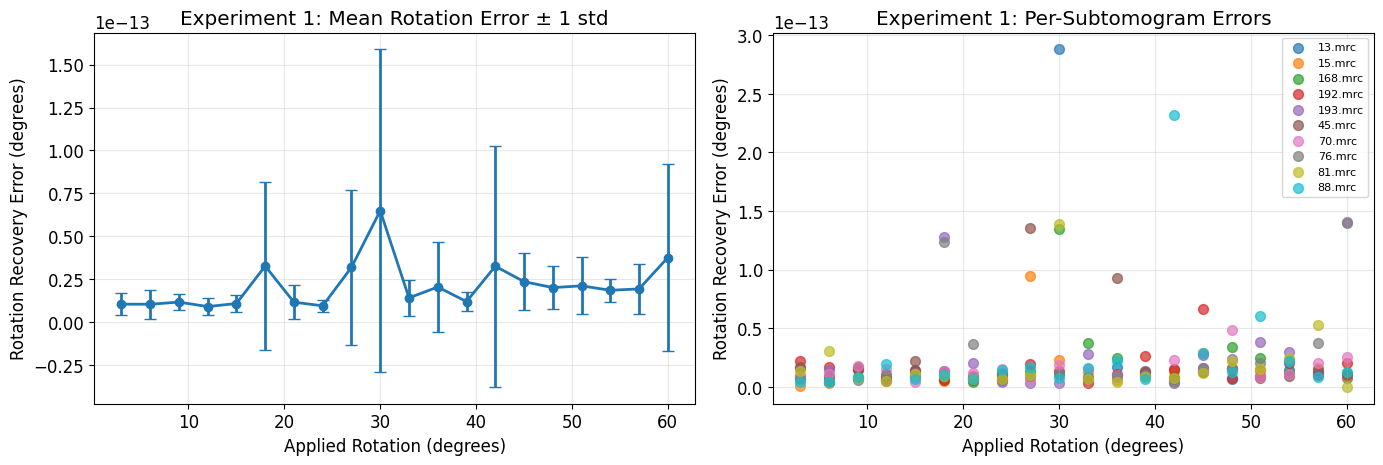

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: mean ± std line plot
stats1 = df_exp1.groupby("theta_deg")["rot_error_deg"].agg(["mean", "std", "median"]).reset_index()

axes[0].errorbar(stats1["theta_deg"], stats1["mean"], yerr=stats1["std"],
                  marker="o", capsize=4, linewidth=2, markersize=6)
axes[0].set_xlabel("Applied Rotation (degrees)")
axes[0].set_ylabel("Rotation Recovery Error (degrees)")
axes[0].set_title("Experiment 1: Mean Rotation Error ± 1 std")
axes[0].grid(True, alpha=0.3)

# Right: per-subtomogram scatter
for name, grp in df_exp1.groupby("file"):
    axes[1].scatter(grp["theta_deg"], grp["rot_error_deg"], label=name, alpha=0.7, s=50)
axes[1].set_xlabel("Applied Rotation (degrees)")
axes[1].set_ylabel("Rotation Recovery Error (degrees)")
axes[1].set_title("Experiment 1: Per-Subtomogram Errors")
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Experiment 2 — Translation-Only Recovery

For each translation magnitude, we:
1. Generate a random-direction translation of that magnitude.
2. Translate the point cloud.
3. Run the EMPOT alignment to recover the translation.
4. Measure the Euclidean error between recovered and true translation vectors.

In [19]:
results_exp2 = []

for t_mag in translation_magnitudes:
    print(f"\n── |t| = {t_mag} ──")
    for idx, (path, pts) in enumerate(zip(selected_paths, sampled_clouds)):
        direction = random_direction(rng)
        t_true = t_mag * direction

        pts_translated = pts + t_true

        t0 = time.time()
        Abar, Bbar, R_recovered, dist = run_empot_alignment(pts, pts_translated)
        runtime = time.time() - t0

        R_true_identity = Rotation.identity()
        t_err = translation_error(t_true, R_true_identity, Abar, Bbar, R_recovered)

        results_exp2.append({
            "file": path.name,
            "t_mag": t_mag,
            "trans_error": t_err,
            "ugw_dist": dist,
            "runtime_sec": runtime,
        })
        print(f"  {path.name}: error = {t_err:.3f}, time = {runtime:.1f}s")

df_exp2 = pd.DataFrame(results_exp2)
print(f"\n── Experiment 2 complete: {len(df_exp2)} trials ──")
df_exp2


── |t| = 1 ──
  81.mrc: error = 0.000, time = 3.0s
  45.mrc: error = 0.000, time = 7.0s
  13.mrc: error = 0.000, time = 3.8s
  76.mrc: error = 0.000, time = 3.5s
  168.mrc: error = 0.000, time = 3.6s
  88.mrc: error = 0.000, time = 5.6s
  15.mrc: error = 0.000, time = 5.0s
  192.mrc: error = 0.000, time = 4.1s
  70.mrc: error = 0.000, time = 4.8s
  193.mrc: error = 0.000, time = 3.6s

── |t| = 2 ──
  81.mrc: error = 0.000, time = 4.8s
  45.mrc: error = 0.000, time = 11.5s
  13.mrc: error = 0.000, time = 6.3s
  76.mrc: error = 0.000, time = 3.6s
  168.mrc: error = 0.000, time = 5.1s
  88.mrc: error = 0.000, time = 11.9s
  15.mrc: error = 0.000, time = 11.1s
  192.mrc: error = 0.000, time = 3.9s
  70.mrc: error = 0.000, time = 6.7s
  193.mrc: error = 0.000, time = 3.6s

── |t| = 3 ──
  81.mrc: error = 0.000, time = 3.0s
  45.mrc: error = 0.000, time = 3.3s
  13.mrc: error = 0.000, time = 6.6s
  76.mrc: error = 0.000, time = 3.0s
  168.mrc: error = 0.000, time = 4.5s
  88.mrc: error = 0.

,file,t_mag,trans_error,ugw_dist,runtime_sec
0,81.mrc,1,4.177744e-15,2.541012,3.027252
1,45.mrc,1,3.775166e-15,0.009346,7.013189
2,13.mrc,1,2.154233e-15,0.834675,3.847178
3,76.mrc,1,1.414241e-15,0.032472,3.513259
4,168.mrc,1,2.281366e-15,0.010037,3.640063
5,88.mrc,1,4.871084e-16,0.064629,5.580695
6,15.mrc,1,3.782913e-15,0.090465,5.005388
7,192.mrc,1,3.012471e-15,0.043710,4.135525
8,70.mrc,1,1.128120e-15,0.000012,4.825206
9,193.mrc,1,1.499058e-15,0.001815,3.587441


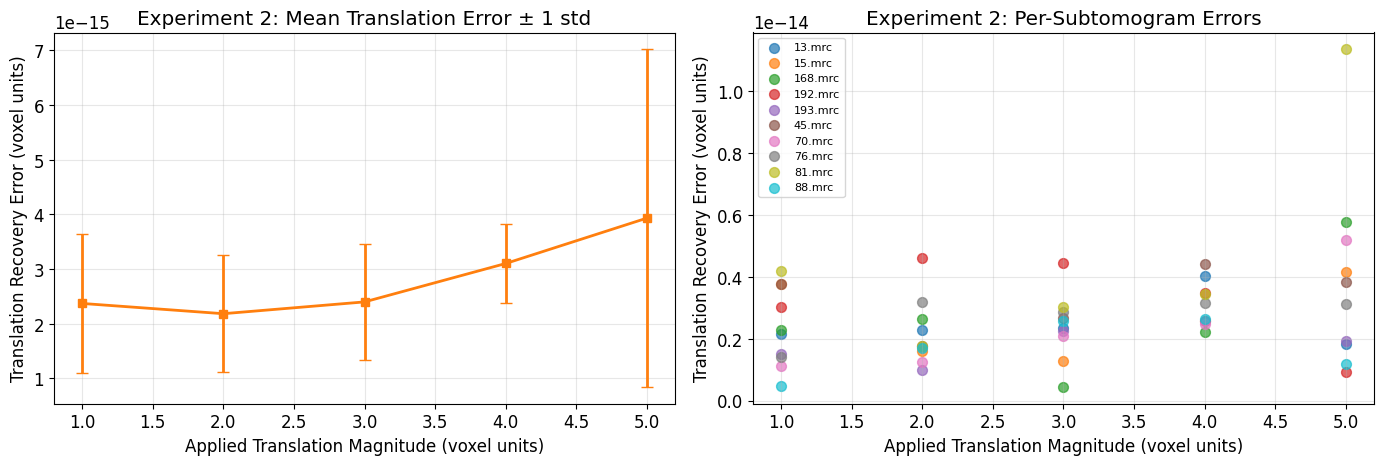

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

stats2 = df_exp2.groupby("t_mag")["trans_error"].agg(["mean", "std", "median"]).reset_index()

axes[0].errorbar(stats2["t_mag"], stats2["mean"], yerr=stats2["std"],
                  marker="s", capsize=4, linewidth=2, markersize=6, color="tab:orange")
axes[0].set_xlabel("Applied Translation Magnitude (voxel units)")
axes[0].set_ylabel("Translation Recovery Error (voxel units)")
axes[0].set_title("Experiment 2: Mean Translation Error ± 1 std")
axes[0].grid(True, alpha=0.3)

for name, grp in df_exp2.groupby("file"):
    axes[1].scatter(grp["t_mag"], grp["trans_error"], label=name, alpha=0.7, s=50)
axes[1].set_xlabel("Applied Translation Magnitude (voxel units)")
axes[1].set_ylabel("Translation Recovery Error (voxel units)")
axes[1].set_title("Experiment 2: Per-Subtomogram Errors")
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Experiment 3 — Combined Rotation + Translation Recovery

For each (θ, |t|) pair, we:
1. Apply a random rotation of magnitude θ **and** a random translation of magnitude |t|.
2. Run the EMPOT alignment to recover both.
3. Measure rotation error and translation error separately.

In [21]:
results_exp3 = []

for theta_deg, t_mag in combined_pairs:
    theta_rad = np.deg2rad(theta_deg)
    print(f"\n── θ = {theta_deg}°, |t| = {t_mag} ──")
    for idx, (path, pts) in enumerate(zip(selected_paths, sampled_clouds)):
        axis = random_axis(rng)
        direction = random_direction(rng)

        R_true = Rotation.from_rotvec(theta_rad * axis)
        t_true = t_mag * direction

        pts_transformed = R_true.apply(pts) + t_true

        t0 = time.time()
        Abar, Bbar, R_recovered, dist = run_empot_alignment(pts, pts_transformed)
        runtime = time.time() - t0

        rot_err = rotation_error_deg(R_true, R_recovered)
        t_err = translation_error(t_true, R_true, Abar, Bbar, R_recovered)

        results_exp3.append({
            "file": path.name,
            "theta_deg": theta_deg,
            "t_mag": t_mag,
            "rot_error_deg": rot_err,
            "trans_error": t_err,
            "ugw_dist": dist,
            "runtime_sec": runtime,
        })
        print(f"  {path.name}: rot_err = {rot_err:.2f}°, trans_err = {t_err:.3f}, time = {runtime:.1f}s")

df_exp3 = pd.DataFrame(results_exp3)
print(f"\n── Experiment 3 complete: {len(df_exp3)} trials ──")
df_exp3


── θ = 5°, |t| = 2 ──
  81.mrc: rot_err = 0.00°, trans_err = 0.000, time = 5.9s
  45.mrc: rot_err = 0.00°, trans_err = 0.000, time = 7.2s
  13.mrc: rot_err = 0.00°, trans_err = 0.000, time = 4.2s
  76.mrc: rot_err = 0.00°, trans_err = 0.000, time = 3.2s
  168.mrc: rot_err = 0.00°, trans_err = 0.000, time = 5.1s
  88.mrc: rot_err = 0.00°, trans_err = 0.000, time = 12.1s
  15.mrc: rot_err = 0.00°, trans_err = 0.000, time = 3.5s
  192.mrc: rot_err = 0.00°, trans_err = 0.000, time = 3.4s
  70.mrc: rot_err = 0.00°, trans_err = 0.000, time = 4.9s
  193.mrc: rot_err = 0.00°, trans_err = 0.000, time = 5.3s

── θ = 10°, |t| = 5 ──
  81.mrc: rot_err = 0.00°, trans_err = 0.000, time = 8.4s
  45.mrc: rot_err = 0.00°, trans_err = 0.000, time = 7.2s
  13.mrc: rot_err = 0.00°, trans_err = 0.000, time = 6.1s
  76.mrc: rot_err = 0.00°, trans_err = 0.000, time = 5.2s
  168.mrc: rot_err = 0.00°, trans_err = 0.000, time = 9.3s
  88.mrc: rot_err = 0.00°, trans_err = 0.000, time = 12.8s
  15.mrc: rot_err =

,file,theta_deg,t_mag,rot_error_deg,trans_error,ugw_dist,runtime_sec
0,81.mrc,5,2,1.164332e-14,1.844441e-15,2.541012,5.853559
1,45.mrc,5,2,1.197250e-14,7.142478e-15,0.009346,7.211438
2,13.mrc,5,2,3.106731e-15,4.088275e-15,0.834675,4.195662
3,76.mrc,5,2,6.074640e-15,2.013762e-15,0.032472,3.214766
4,168.mrc,5,2,7.389843e-15,3.257705e-15,0.010037,5.086716
5,88.mrc,5,2,6.094040e-15,3.159750e-15,0.064629,12.124660
6,15.mrc,5,2,9.910245e-15,2.994034e-15,0.090465,3.521903
7,192.mrc,5,2,3.490097e-15,3.427336e-15,0.043710,3.401016
8,70.mrc,5,2,1.940783e-14,2.186886e-15,0.000012,4.913362
9,193.mrc,5,2,6.118565e-15,2.730788e-15,0.001815,5.268352


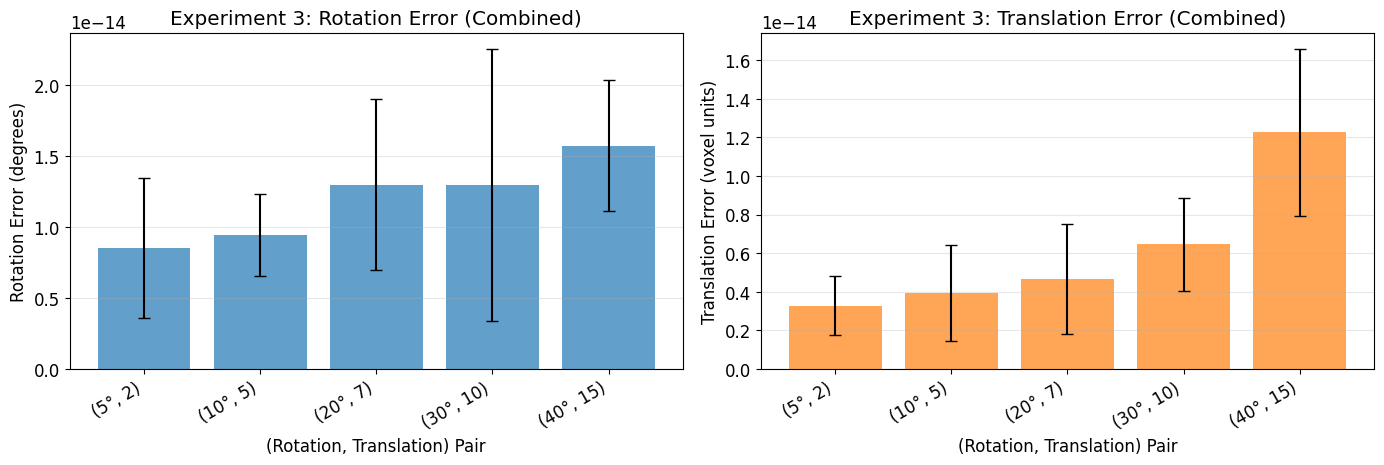

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Create readable pair labels
pair_labels = [f"({td}°, {tm})" for td, tm in combined_pairs]
df_exp3["pair_label"] = df_exp3.apply(
    lambda r: f"({int(r.theta_deg)}°, {int(r.t_mag)})", axis=1
)

stats3_rot = df_exp3.groupby("pair_label")["rot_error_deg"].agg(["mean", "std"]).reindex(pair_labels)
stats3_trans = df_exp3.groupby("pair_label")["trans_error"].agg(["mean", "std"]).reindex(pair_labels)

x_pos = range(len(pair_labels))

axes[0].bar(x_pos, stats3_rot["mean"], yerr=stats3_rot["std"],
            capsize=4, color="tab:blue", alpha=0.7)
axes[0].set_xticks(list(x_pos))
axes[0].set_xticklabels(pair_labels, rotation=30, ha="right")
axes[0].set_xlabel("(Rotation, Translation) Pair")
axes[0].set_ylabel("Rotation Error (degrees)")
axes[0].set_title("Experiment 3: Rotation Error (Combined)")
axes[0].grid(True, alpha=0.3, axis="y")

axes[1].bar(x_pos, stats3_trans["mean"], yerr=stats3_trans["std"],
            capsize=4, color="tab:orange", alpha=0.7)
axes[1].set_xticks(list(x_pos))
axes[1].set_xticklabels(pair_labels, rotation=30, ha="right")
axes[1].set_xlabel("(Rotation, Translation) Pair")
axes[1].set_ylabel("Translation Error (voxel units)")
axes[1].set_title("Experiment 3: Translation Error (Combined)")
axes[1].grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

## Summary & Export

In [23]:
# ── Summary tables ──────────────────────────────────────────────
print("=" * 65)
print("EXPERIMENT 1: ROTATION-ONLY RECOVERY")
print("=" * 65)
print(stats1.to_string(index=False))

print("" + "=" * 65)
print("EXPERIMENT 2: TRANSLATION-ONLY RECOVERY")
print("=" * 65)
print(stats2.to_string(index=False))

print("" + "=" * 65)
print("EXPERIMENT 3: COMBINED ROTATION + TRANSLATION")
print("=" * 65)
pair_labels_list = [f"({td}°, {tm})" for td, tm in combined_pairs]
stats3_combined = df_exp3.groupby("pair_label").agg({
    "rot_error_deg": ["mean", "std"],
    "trans_error": ["mean", "std"],
    "runtime_sec": "mean",
}).reindex(pair_labels_list)
print(stats3_combined.to_string())

EXPERIMENT 1: ROTATION-ONLY RECOVERY
 theta_deg         mean          std       median
         3 1.059264e-14 6.519373e-15 9.235377e-15
         6 1.055009e-14 8.559588e-15 8.721475e-15
         9 1.179950e-14 4.622545e-15 1.171450e-14
        12 9.190115e-15 4.763243e-15 7.386514e-15
        15 1.096812e-14 4.949149e-15 1.026621e-14
        18 3.275545e-14 4.893150e-14 1.146056e-14
        21 1.174920e-14 9.716795e-15 7.569225e-15
        24 9.634274e-15 3.628390e-15 1.031286e-14
        27 3.199437e-14 4.506633e-14 1.178507e-14
        30 6.497418e-14 9.386086e-14 1.599310e-14
        33 1.426288e-14 1.067216e-14 1.070926e-14
        36 2.057318e-14 2.615096e-14 1.054542e-14
        39 1.209518e-14 5.414629e-15 1.070845e-14
        42 3.266567e-14 7.018098e-14 1.088008e-14
        45 2.367942e-14 1.667659e-14 1.604020e-14
        48 2.023584e-14 1.269459e-14 1.604897e-14
        51 2.123840e-14 1.662745e-14 1.496603e-14
        54 1.867937e-14 6.724289e-15 2.054565e-14
        57 1.

## Runtime Analysis

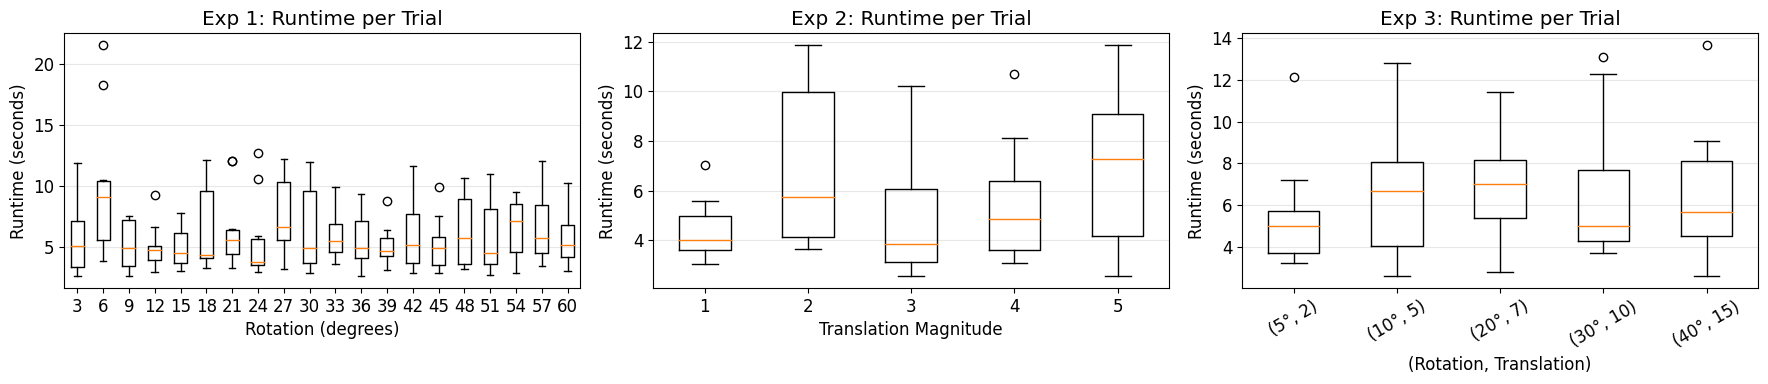

Total experiment runtime: 1829s (30.5 min)


In [24]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].boxplot(
    [df_exp1[df_exp1["theta_deg"] == t]["runtime_sec"] for t in rotation_angles_deg],
    labels=[str(t) for t in rotation_angles_deg],
)
axes[0].set_xlabel("Rotation (degrees)")
axes[0].set_ylabel("Runtime (seconds)")
axes[0].set_title("Exp 1: Runtime per Trial")
axes[0].grid(True, alpha=0.3, axis="y")

axes[1].boxplot(
    [df_exp2[df_exp2["t_mag"] == t]["runtime_sec"] for t in translation_magnitudes],
    labels=[str(t) for t in translation_magnitudes],
)
axes[1].set_xlabel("Translation Magnitude")
axes[1].set_ylabel("Runtime (seconds)")
axes[1].set_title("Exp 2: Runtime per Trial")
axes[1].grid(True, alpha=0.3, axis="y")

axes[2].boxplot(
    [df_exp3[df_exp3["pair_label"] == lbl]["runtime_sec"] for lbl in pair_labels],
    labels=pair_labels,
)
axes[2].set_xlabel("(Rotation, Translation)")
axes[2].set_ylabel("Runtime (seconds)")
axes[2].set_title("Exp 3: Runtime per Trial")
axes[2].tick_params(axis="x", rotation=30)
axes[2].grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

total_time = df_exp1["runtime_sec"].sum() + df_exp2["runtime_sec"].sum() + df_exp3["runtime_sec"].sum()
print(f"Total experiment runtime: {total_time:.0f}s ({total_time/60:.1f} min)")

## Verification: Correctness Tests

**Test 1 — Trivial-case tests**: Apply known trivial transforms (identity rotation, zero translation,
known 90° rotation, known translation) and verify the pipeline recovers them exactly.

**Test 2 — Reconstruction test**: Apply a known rotation + translation, recover the transform,
apply it back to the perturbed cloud, and measure RMSD against the original. Should be near zero.

In [ ]:
# ── Use the first pre-sampled cloud for all verification tests ──
pts = sampled_clouds[0]
print(f"Verification cloud: {selected_paths[0].name}  ({pts.shape[0]} points)\n")

PASS_MARK = "\u2705 PASS"
FAIL_MARK = "\u274c FAIL"
all_passed = True

# ═══════════════════════════════════════════════════════════════
# TEST 1a — Zero rotation (identity)
# ═══════════════════════════════════════════════════════════════
R_id = Rotation.identity()
pts_same = R_id.apply(pts)  # no-op

Abar, Bbar, R_rec, dist = run_empot_alignment(pts, pts_same)
err = rotation_error_deg(R_id, R_rec)
print(err)
status = PASS_MARK if err < 1.0 else FAIL_MARK
if err >= 1.0: all_passed = False
print(f"Test 1a  Zero rotation:         rot_error = {err:.4f}\u00b0   (expect \u2248 0\u00b0)  {status}")

# ═══════════════════════════════════════════════════════════════
# TEST 1b — Zero translation
# ═══════════════════════════════════════════════════════════════
t_zero = np.array([0.0, 0.0, 0.0])
pts_same = pts + t_zero

Abar, Bbar, R_rec, dist = run_empot_alignment(pts, pts_same)
t_err = translation_error(t_zero, Rotation.identity(), Abar, Bbar, R_rec)
status = PASS_MARK if t_err < 0.5 else FAIL_MARK
if t_err >= 0.5: all_passed = False
print(f"Test 1b  Zero translation:      trans_error = {t_err:.4f}  (expect \u2248 0)  {status}")

# ═══════════════════════════════════════════════════════════════
# TEST 1c — Known 90\u00b0 rotation around z-axis
# ═══════════════════════════════════════════════════════════════
R_90z = Rotation.from_rotvec(np.deg2rad(90) * np.array([0, 0, 1]))
pts_rot90 = R_90z.apply(pts)

Abar, Bbar, R_rec, dist = run_empot_alignment(pts, pts_rot90)
err = rotation_error_deg(R_90z, R_rec)
status = PASS_MARK if err < 5.0 else FAIL_MARK
if err >= 5.0: all_passed = False
print(f"Test 1c  90\u00b0 rotation (z-axis): rot_error = {err:.4f}\u00b0   (expect < 5\u00b0)  {status}")

# Also verify the residual rotation vector is near zero
R_diff = R_rec * R_90z
rotvec_diff = R_diff.as_rotvec()
print(f"         R_recovered * R_true rotvec = [{rotvec_diff[0]:.4f}, {rotvec_diff[1]:.4f}, {rotvec_diff[2]:.4f}]  (expect \u2248 [0,0,0])")

# ═══════════════════════════════════════════════════════════════
# TEST 1d — Known translation [5, 0, 0]
# ═══════════════════════════════════════════════════════════════
t_known = np.array([5.0, 0.0, 0.0])
pts_trans = pts + t_known

Abar, Bbar, R_rec, dist = run_empot_alignment(pts, pts_trans)
t_err = translation_error(t_known, Rotation.identity(), Abar, Bbar, R_rec)
t_rec = Abar - R_rec.apply(Bbar)
status = PASS_MARK if t_err < 1.0 else FAIL_MARK
if t_err >= 1.0: all_passed = False
print(f"Test 1d  Translation [5,0,0]:   trans_error = {t_err:.4f}  (expect < 1)  {status}")
print(f"         Recovered inv-translation = [{t_rec[0]:.3f}, {t_rec[1]:.3f}, {t_rec[2]:.3f}]  (expect \u2248 [-5, 0, 0])")

# ═══════════════════════════════════════════════════════════════
# TEST 2 — Reconstruction test (known rotation + translation)
# ═══════════════════════════════════════════════════════════════
print("\n" + "=" * 65)
R_test = Rotation.from_rotvec(np.deg2rad(30) * np.array([1, 1, 0]) / np.sqrt(2))
t_test = np.array([3.0, -2.0, 1.5])
pts_transformed = R_test.apply(pts) + t_test

Abar, Bbar, R_rec, dist = run_empot_alignment(pts, pts_transformed)

# Reconstruct: apply recovered inverse transform to the perturbed cloud
pts_reconstructed = R_rec.apply(pts_transformed - Bbar) + Abar

# Nearest-neighbor RMSD (correspondences may not be exactly 1-to-1)
from scipy.spatial import cKDTree
tree = cKDTree(pts)
dists, _ = tree.query(pts_reconstructed)
rmsd = np.sqrt(np.mean(dists ** 2))

rot_err = rotation_error_deg(R_test, R_rec)
t_err = translation_error(t_test, R_test, Abar, Bbar, R_rec)

status_rot = PASS_MARK if rot_err < 5.0 else FAIL_MARK
status_t = PASS_MARK if t_err < 2.0 else FAIL_MARK
status_rmsd = PASS_MARK if rmsd < 2.0 else FAIL_MARK
if rot_err >= 5.0 or t_err >= 2.0 or rmsd >= 2.0: all_passed = False

print(f"Test 2   Reconstruction (30\u00b0 + translation)")
print(f"         rot_error  = {rot_err:.4f}\u00b0    (expect < 5\u00b0)   {status_rot}")
print(f"         trans_error = {t_err:.4f}     (expect < 2)    {status_t}")
print(f"         RMSD       = {rmsd:.4f}       (expect < 2)    {status_rmsd}")

print("\n" + "=" * 65)
if all_passed:
    print(f"{PASS_MARK}  All verification tests passed.")
else:
    print(f"{FAIL_MARK}  Some verification tests failed \u2014 review the results above.")

Verification cloud: 81.mrc  (500 points)

1.0521043559198391e-13
Test 1a  Zero rotation:         rot_error = 0.0000°   (expect ≈ 0°)  ✅ PASS
2.359757039457445e-15
Test 1b  Zero translation:      trans_error = 0.0000  (expect ≈ 0)  ✅ PASS
1.6110145246029128e-14
Test 1c  90° rotation (z-axis): rot_error = 0.0000°   (expect < 5°)  ✅ PASS
         R_recovered * R_true rotvec = [-0.0000, -0.0000, 0.0000]  (expect ≈ [0,0,0])
Test 1d  Translation [5,0,0]:   trans_error = 0.0000  (expect < 1)  ✅ PASS
         Recovered inv-translation = [-5.000, -0.000, -0.000]  (expect ≈ [-5, 0, 0])

Test 2   Reconstruction (30° + translation)
         rot_error  = 0.0000°    (expect < 5°)   ✅ PASS
         trans_error = 0.0000     (expect < 2)    ✅ PASS
         RMSD       = 0.0000       (expect < 2)    ✅ PASS

✅ PASS  All verification tests passed.
